In [1]:
import os, random
import numpy as np
import tensorflow as tf

SEED = 42  # choose any integer

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


In [2]:
import pandas as pd
import numpy as np
import mne

In [3]:
import mne

fname = r"D:\EEG DATA\Dataset\dataverse_files\s01.edf"  # full or relative path
raw = mne.io.read_raw_edf(fname, preload=True)
print(raw)
print(raw.info)          # metadata: channels, sfreq, etc.
data, times = raw.get_data(return_times=True)

Extracting EDF parameters from D:\EEG DATA\Dataset\dataverse_files\s01.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 211249  =      0.000 ...   844.996 secs...
<RawEDF | s01.edf, 19 x 211250 (845.0 s), ~30.6 MiB, data loaded>
<Info | 8 non-empty values
 bads: []
 ch_names: Fp2, F8, T4, T6, O2, Fp1, F7, T3, T5, O1, F4, C4, P4, F3, C3, ...
 chs: 19 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 125.0 Hz
 meas_date: 2004-08-20 12:19:24 UTC
 nchan: 19
 projs: []
 sfreq: 250.0 Hz
 subject_info: <subject_info | his_id: OJS>
>


Using matplotlib as 2D backend.


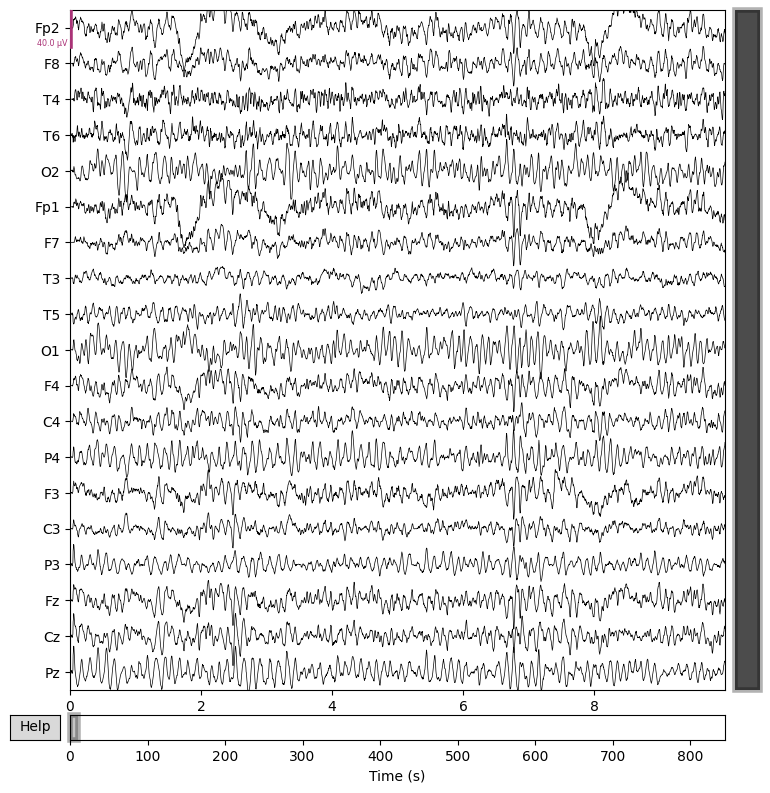

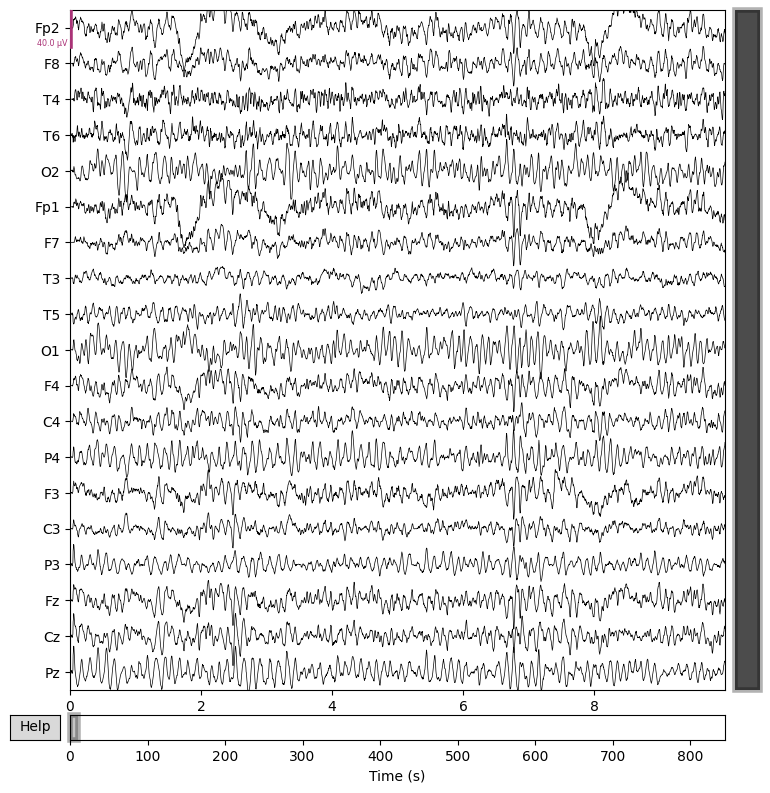

In [4]:
raw.plot()

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 1651 samples (6.604 s)

Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).


C:\Users\Manisha\AppData\Local\Temp\ipykernel_22180\524655454.py:1: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  raw.filter(0.5, 40); raw.compute_psd().plot()
f:\Anaconda\envs\new_env\Lib\site-packages\mne\viz\utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


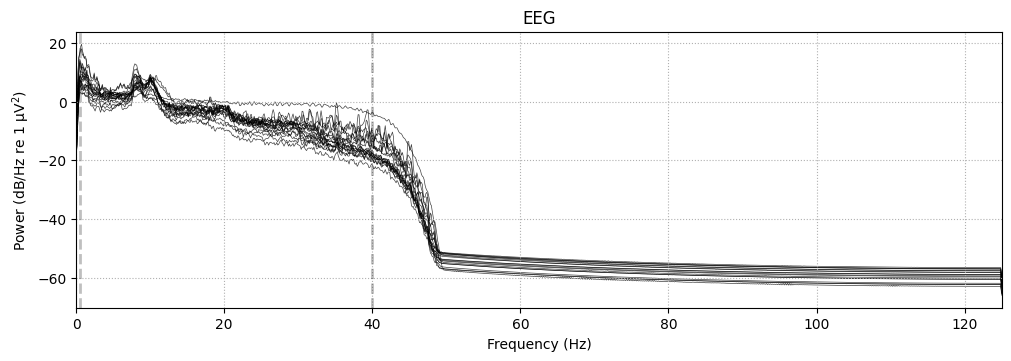

In [5]:
raw.filter(0.5, 40); raw.compute_psd().plot()

In [6]:
raw = raw.set_eeg_reference(ref_channels='average')                                    ####    average reference method  #######

EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.


In [7]:
from mne import make_fixed_length_epochs

epochs = make_fixed_length_epochs(raw, duration=1, overlap=0)                    
print(epochs.info)
print(len(epochs.events))

Not setting metadata
845 matching events found
No baseline correction applied
0 projection items activated
<Info | 9 non-empty values
 bads: []
 ch_names: Fp2, F8, T4, T6, O2, Fp1, F7, T3, T5, O1, F4, C4, P4, F3, C3, ...
 chs: 19 EEG
 custom_ref_applied: True
 highpass: 0.5 Hz
 lowpass: 40.0 Hz
 meas_date: 2004-08-20 12:19:24 UTC
 nchan: 19
 projs: []
 sfreq: 250.0 Hz
 subject_info: <subject_info | his_id: OJS>
>
845


Using data from preloaded Raw for 845 events and 250 original time points ...
0 bad epochs dropped
Using data from preloaded Raw for 20 events and 250 original time points ...


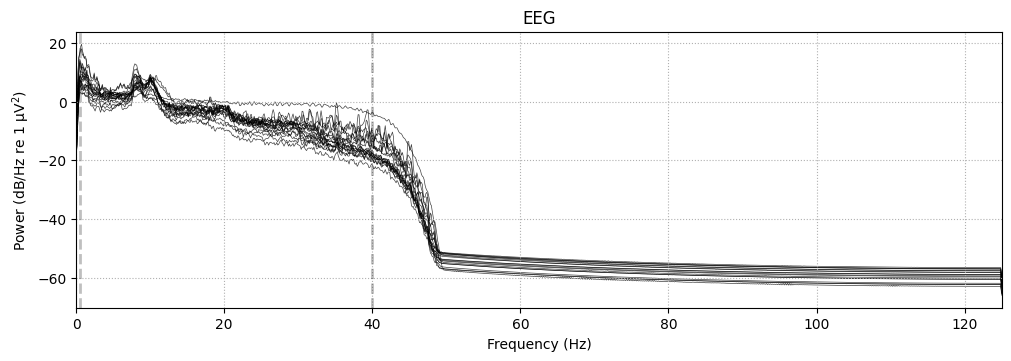

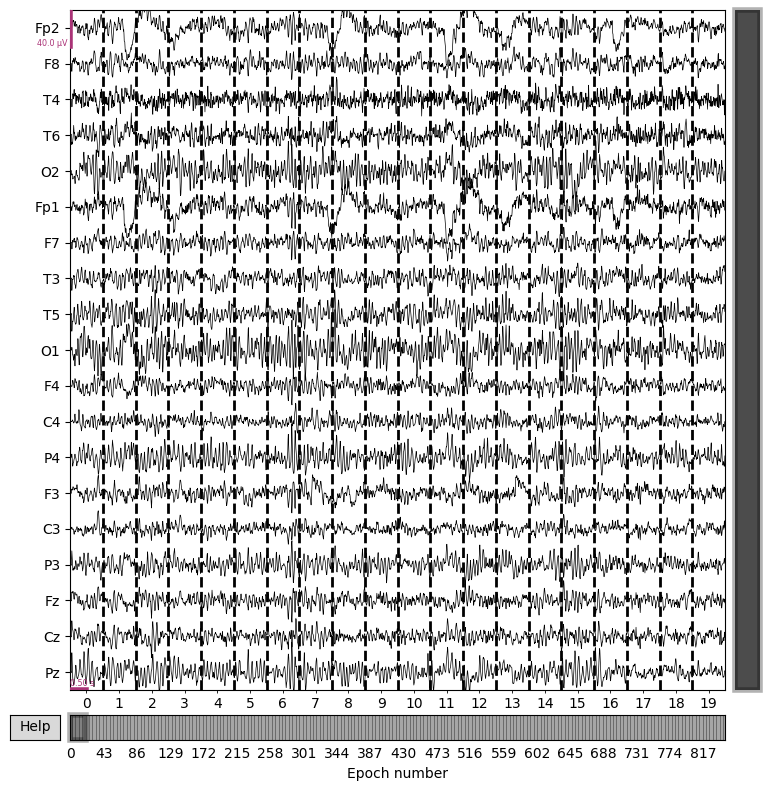

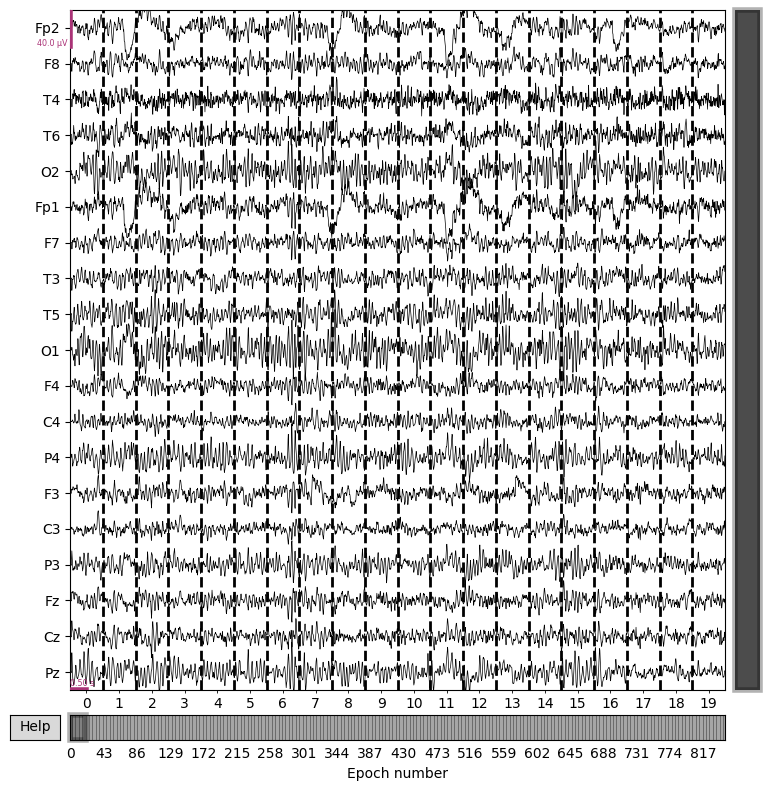

In [8]:
epochs.plot()

In [9]:
epochs.info

<Info | 9 non-empty values
 bads: []
 ch_names: Fp2, F8, T4, T6, O2, Fp1, F7, T3, T5, O1, F4, C4, P4, F3, C3, ...
 chs: 19 EEG
 custom_ref_applied: True
 highpass: 0.5 Hz
 lowpass: 40.0 Hz
 meas_date: 2004-08-20 12:19:24 UTC
 nchan: 19
 projs: []
 sfreq: 250.0 Hz
 subject_info: <subject_info | his_id: OJS>
>

In [10]:
import glob, os
import mne
import numpy as np

folder = r"D:\EEG DATA\Dataset\dataverse_files"          # your folder
edf_paths = glob.glob(os.path.join(folder, "*.edf"))

X_list = []
y_list = []

for path in edf_paths:
    fname = os.path.basename(path).lower()

    # 1 = seizure, 0 = healthy  (edit these rules to match your filenames)
    if "s" in fname or "sz" in fname:
        label = 1
    elif "h" in fname or "nonseizure" in fname or "nsz" in fname:
        label = 0
    else:
        continue  # skip files you cannot classify

    raw = mne.io.read_raw_edf(path, preload=True)
    raw.filter(0.5, 40.)

    from mne import make_fixed_length_epochs
    epochs = make_fixed_length_epochs(raw, duration=1.0, overlap=0.0, preload=True)

    X = epochs.get_data()              # (n_epochs, n_ch, n_times)
    y = np.full(len(epochs), label)    # same label for all epochs of this file

    X_list.append(X)
    y_list.append(y)

# concatenate all files
X_all = np.concatenate(X_list, axis=0)
y_all = np.concatenate(y_list, axis=0)


Extracting EDF parameters from D:\EEG DATA\Dataset\dataverse_files\h01.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 231249  =      0.000 ...   924.996 secs...
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 1651 samples (6.604 s)

Not setting metadata
925 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 925 events and 250 original time points ...
0 bad epochs dropped
Extracting E

In [11]:
print(X_all.shape)
print(y_all.shape)

(28863, 19, 250)
(28863,)


In [12]:
X_all

array([[[ 4.23516474e-21, -2.47779947e-08,  1.72764588e-07, ...,
          1.37127547e-05,  1.42966276e-05,  1.26946585e-05],
        [ 0.00000000e+00, -5.72222878e-08,  1.61908404e-07, ...,
          1.49119494e-05,  1.38694140e-05,  1.12490494e-05],
        [-1.48230766e-21, -1.43897138e-07,  4.82047558e-08, ...,
          4.17972090e-07,  9.98210718e-08, -1.33651433e-06],
        ...,
        [ 2.11758237e-22, -4.35172972e-08, -4.13341861e-08, ...,
          4.01685978e-06,  3.71024050e-06,  2.11683143e-06],
        [-7.62329653e-21, -3.91950420e-08, -3.49108894e-08, ...,
          3.09098437e-07,  2.38458879e-06,  5.77473149e-06],
        [ 7.19978005e-21, -8.38556749e-08, -1.55880204e-07, ...,
         -6.00710525e-06, -2.50022040e-06,  2.01148186e-06]],

       [[ 1.03262760e-05,  9.27648136e-06,  1.04591411e-05, ...,
          4.70201941e-06,  3.65290594e-06,  2.03068070e-06],
        [ 9.14247833e-06,  9.59003426e-06,  1.29384775e-05, ...,
         -3.08329167e-06, -5.44239467e

In [13]:
import numpy as np

X_1 = X_all.astype(np.float32)
chunk = 1000
for i in range(0, X_1.shape[0], chunk):
    sl = slice(i, i+chunk)
    mean = X_1[sl].mean(axis=-1, keepdims=True)
    std  = X_1[sl].std(axis=-1, keepdims=True) + 1e-8
    X_1[sl] = (X_1[sl] - mean) / std      # in-place scaling


In [14]:
X_1.shape

(28863, 19, 250)

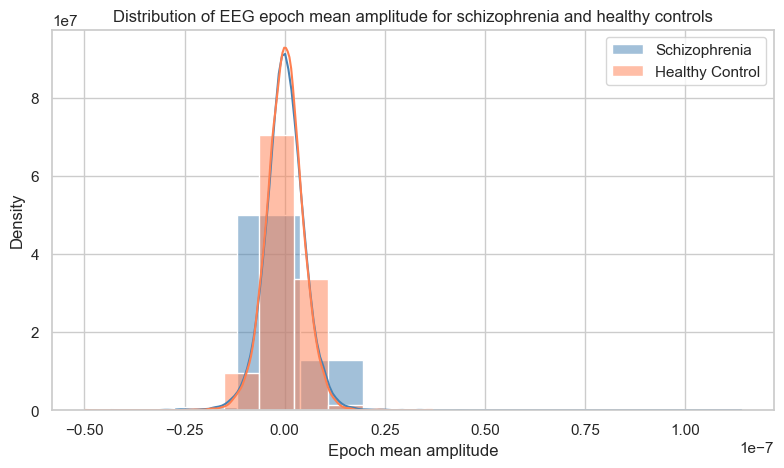

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

# 1) compute mean per epoch (global mean over channels & time)
epoch_means = X_1.mean(axis=(1, 2))      # shape: (n_epochs,)

# 2) split by class
means_scz = epoch_means[y_all == 1]
means_hc  = epoch_means[y_all == 0]

# 3) plot distributions
plt.figure(figsize=(8,5))
sns.histplot(means_scz, color="steelblue", kde=True, stat="density",
             label="Schizophrenia", alpha=0.5, bins=10)
sns.histplot(means_hc,  color="coral",    kde=True, stat="density",
             label="Healthy Control", alpha=0.5, bins=10)

plt.xlabel("Epoch mean amplitude")
plt.ylabel("Density")
plt.title("Distribution of EEG epoch mean amplitude for schizophrenia and healthy controls")
plt.legend()
plt.tight_layout()
plt.show()


In [16]:
import numpy as np
from scipy.signal import spectrogram

def segment_to_tf_image(seg, fs=250):
    """
    seg : np.ndarray, shape (n_channels, n_times)
    returns : np.ndarray, shape (n_channels, n_freqs, n_time_windows)
    """
    imgs = []
    for ch in range(seg.shape[0]):
        f, t, Sxx = spectrogram(seg[ch], fs=fs, nperseg=64, noverlap=32)
        # Keep only 0-40 Hz
        idx = f <= 40                    # boolean mask
        f = f[idx]                       # new frequency vector
        Sxx = Sxx[idx, :]
        imgs.append(Sxx)                 # (n_freqs, n_time_windows)
    imgs = np.stack(imgs, axis=0)        # (n_channels, n_freqs, n_time_windows)
    return imgs


In [17]:
f, t, Sxx = spectrogram(X_1[0], fs=250, nperseg=64, noverlap=32)
# t is in seconds, length = 6 in your case

print(t)
print(f)


[0.128 0.256 0.384 0.512 0.64  0.768]
[  0.        3.90625   7.8125   11.71875  15.625    19.53125  23.4375
  27.34375  31.25     35.15625  39.0625   42.96875  46.875    50.78125
  54.6875   58.59375  62.5      66.40625  70.3125   74.21875  78.125
  82.03125  85.9375   89.84375  93.75     97.65625 101.5625  105.46875
 109.375   113.28125 117.1875  121.09375 125.     ]


In [18]:
imgs = []
for i in range(len(X_1)):
    seg = X_1[i]
    img = segment_to_tf_image(seg, fs=250)     # (19, f, t)
    imgs.append(np.expand_dims(img, -1))       # (19, f, t, 1)

X_img = np.stack(imgs, axis=0)                 # (N, 19, f, t, 1)

In [19]:
X_img.shape

(28863, 19, 11, 6, 1)

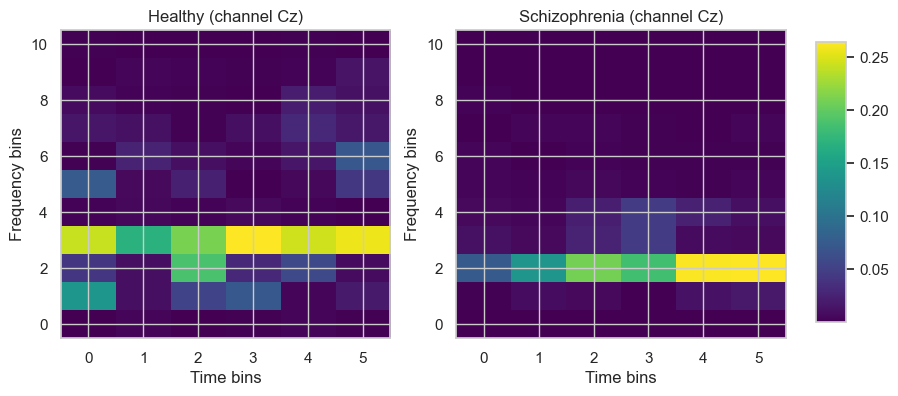

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# indices of a healthy and a schizophrenia epoch
idx_hc  = np.where(y_all == 0)[0][0]
idx_scz = np.where(y_all == 1)[0][0]

# pick one channel, e.g. Cz (replace with its index, say 12)
ch_idx = 12

spec_hc  = X_img[idx_hc,  ch_idx, :, :, 0]   # (F, T)
spec_scz = X_img[idx_scz, ch_idx, :, :, 0]   # (F, T)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

im0 = axes[0].imshow(spec_hc, aspect='auto', origin='lower',
                     cmap='viridis')
axes[0].set_title('Healthy (channel Cz)')
axes[0].set_xlabel('Time bins')
axes[0].set_ylabel('Frequency bins')

im1 = axes[1].imshow(spec_scz, aspect='auto', origin='lower',
                     cmap='viridis')
axes[1].set_title('Schizophrenia (channel Cz)')
axes[1].set_xlabel('Time bins')
axes[1].set_ylabel('Frequency bins')

# move subplots a bit left so colorbar fits
plt.subplots_adjust(right=0.85)

# make colorbar in remaining 15% on the right
cbar_ax = fig.add_axes([0.88, 0.15, 0.03, 0.7])
fig.colorbar(im1, cax=cbar_ax)

plt.show()


In [21]:
import numpy as np

X = X_img          # shape (N, ...)
y = y_all          # shape (N,)
N = len(y)

rng = np.random.default_rng(seed=42)

train_idx = []
val_idx   = []
test_idx  = []

for cls in np.unique(y):
    cls_idx = np.where(y == cls)[0]
    rng.shuffle(cls_idx)

    n_cls   = len(cls_idx)
    n_train = int(0.70 * n_cls)
    n_val   = int(0.20 * n_cls)

    train_idx.extend(cls_idx[:n_train])
    val_idx.extend(cls_idx[n_train:n_train + n_val])
    test_idx.extend(cls_idx[n_train + n_val:])

train_idx = np.array(train_idx)
val_idx   = np.array(val_idx)
test_idx  = np.array(test_idx)

X_train, y_train = X[train_idx], y[train_idx]
X_val,   y_val   = X[val_idx],   y[val_idx]
X_test,  y_test  = X[test_idx],  y[test_idx]


In [22]:
print(X_train.shape, y_train.shape)  # training set
print(X_val.shape,   y_val.shape)     # validation set
print(X_test.shape,  y_test.shape)    # final test set

(20204, 19, 11, 6, 1) (20204,)
(5772, 19, 11, 6, 1) (5772,)
(2887, 19, 11, 6, 1) (2887,)


In [23]:
import numpy as np

y1 = X_test[y_test == 0]  # all rows whose label is 0
y2 = X_test[y_test == 1]  # all rows whose label is 1

print(y1.shape, y2.shape)


(1303, 19, 11, 6, 1) (1584, 19, 11, 6, 1)


C:\Users\Manisha\AppData\Local\Temp\ipykernel_22180\2151230998.py:37: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


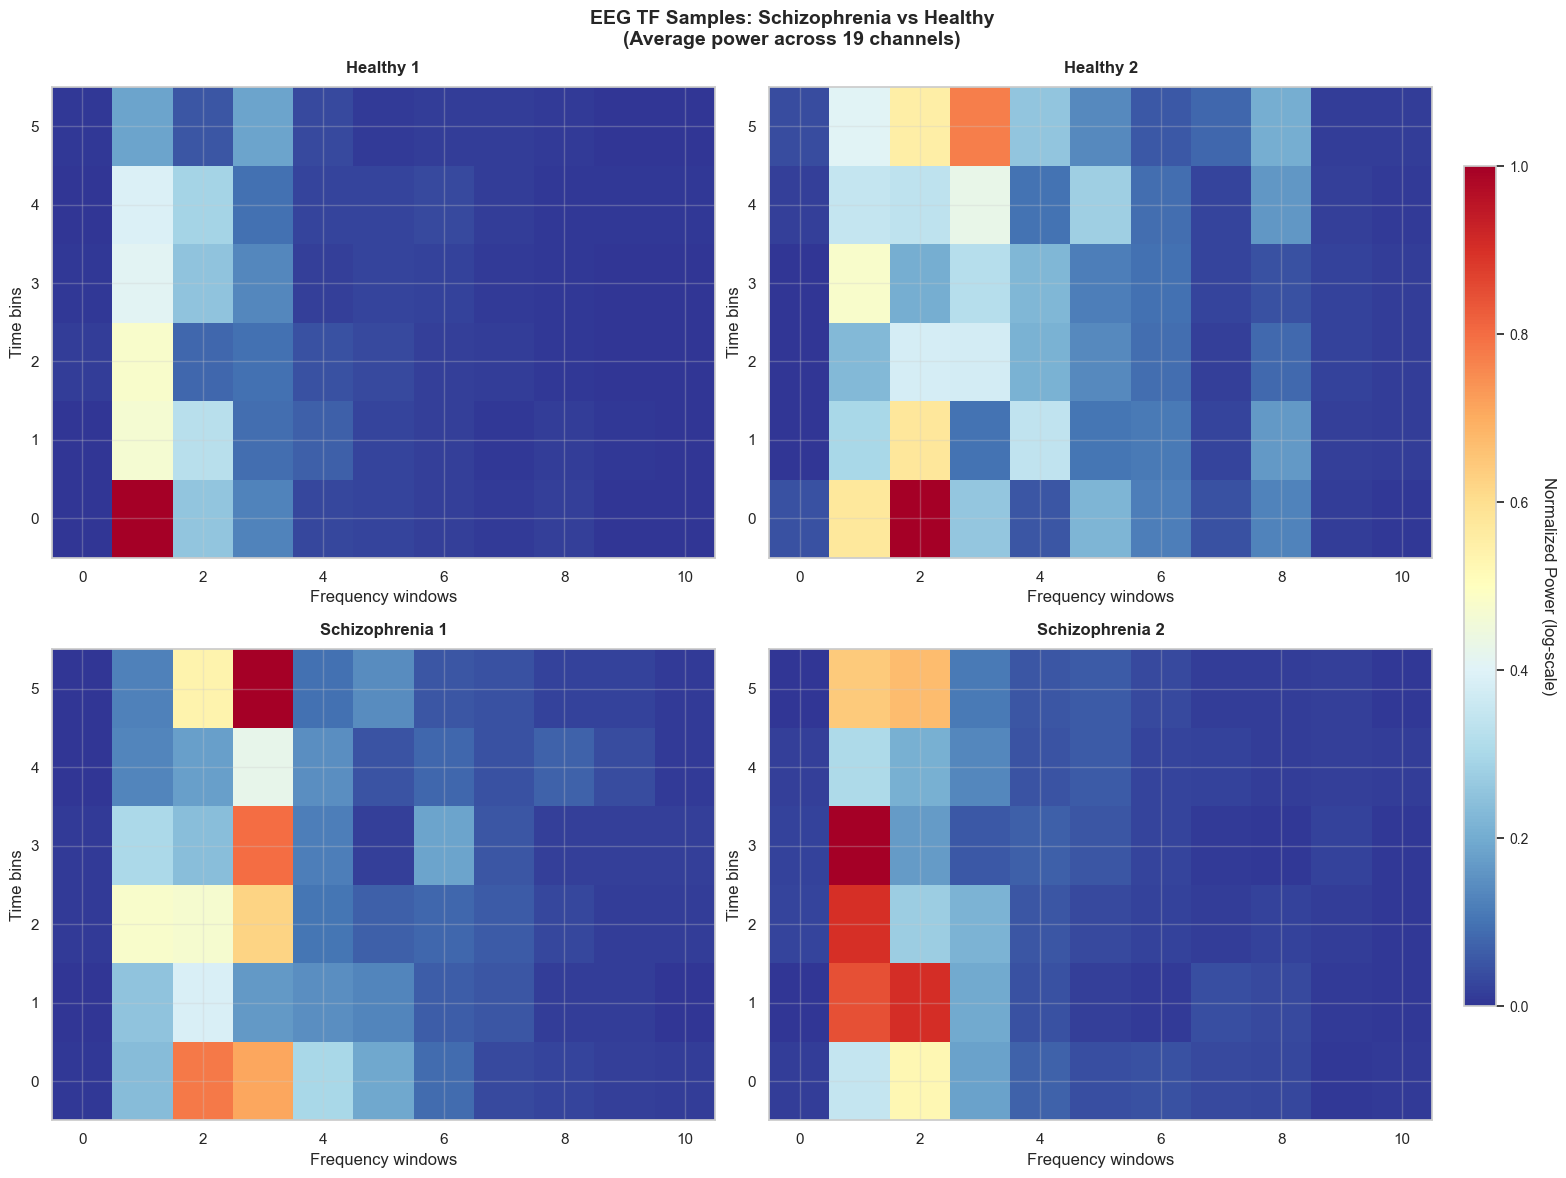

In [24]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Get indices (assuming y_train: 0=non-schizo, 1=schizo)
schizo_idx = np.where(y_train == 1)[0][4:6]
non_schizo_idx = np.where(y_train == 0)[0][4:6]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('EEG TF Samples: Schizophrenia vs Healthy\n(Average power across 19 channels)', 
             fontsize=14, fontweight='bold')

samples = [non_schizo_idx[0], non_schizo_idx[1], schizo_idx[0], schizo_idx[1]]
titles = ['Healthy 1', 'Healthy 2', 'Schizophrenia 1', 'Schizophrenia 2']

for i, (idx, title) in enumerate(zip(samples, titles)):
    row, col = i // 2, i % 2
    
    sample = X_train[idx].squeeze()  # (19,11,6)
    tf_mean = np.log1p(np.mean(sample, axis=0))  # Log-scale average
    tf_norm = (tf_mean - tf_mean.min()) / (tf_mean.max() - tf_mean.min())
    
    im = axes[row, col].imshow(tf_norm.T, cmap='RdYlBu_r', aspect='auto', 
                              origin='lower', vmin=0, vmax=1)
    
    axes[row, col].set_title(title, fontsize=12, fontweight='bold', pad=10)
    axes[row, col].set_xlabel('Frequency windows')
    axes[row, col].set_ylabel('Time bins')
    axes[row, col].grid(True, alpha=0.3)

# Add colorbar to RIGHT of ALL subplots (clearly visible)
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label('Normalized Power (log-scale)', fontsize=12, rotation=270, labelpad=20)
cbar.ax.tick_params(labelsize=10)

plt.tight_layout()
plt.subplots_adjust(right=0.90)  # Make space for colorbar
plt.show()


In [25]:
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.losses import BinaryCrossentropy   # correct


inputs = layers.Input(shape=(19, 11, 6, 1))  # (channels, freq, time, 1)

def eeg_inception_block(x, f=16, l2=1e-4):
    b1 = layers.Conv3D(f, (3, 1, 1), padding='same', activation='relu',
                       kernel_regularizer=regularizers.l2(l2))(x)
    b2 = layers.Conv3D(f, (1, 3, 1), padding='same', activation='relu',
                       kernel_regularizer=regularizers.l2(l2))(x)
    b3 = layers.Conv3D(f, (1, 1, 3), padding='same', activation='relu',
                       kernel_regularizer=regularizers.l2(l2))(x)

    x = layers.Concatenate(axis=-1)([b1, b2, b3])
    x = layers.Conv3D(32, (1, 1, 1), padding='same', activation='relu',
                      kernel_regularizer=regularizers.l2(l2))(x)
    x = layers.BatchNormalization()(x)
    return x


x = eeg_inception_block(inputs)
x = layers.MaxPool3D((2, 2, 2), padding='same')(x)
x = layers.Dropout(0.2)(x)

# Then continue with your existing Conv3D blocks (maybe with slightly fewer filters)
x = layers.Conv3D(32, (3,3,3), padding='same', activation='relu',
                  kernel_regularizer=regularizers.l2(1e-4))(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPool3D((2,2,2), padding='same')(x)
x = layers.Dropout(0.3)(x)

x = layers.Conv3D(16, (3,3,3), padding='same', activation='relu',
                  kernel_regularizer=regularizers.l2(1e-4))(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPool3D((2,2,1), padding='same')(x)
x = layers.Dropout(0.4)(x)

x = layers.Flatten()(x)
x = layers.Dense(8, activation='relu',
                 kernel_regularizer=regularizers.l2(1e-4))(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(2, activation='softmax')(x)

model = models.Model(inputs=inputs, outputs=outputs)


In [26]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 19, 11, 6, │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d (Conv3D)     │ (None, 19, 11, 6, │         64 │ input_layer[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_1 (Conv3D)   │ (None, 19, 11, 6, │         64 │ input_layer[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_2 (Conv3D)   │ (None, 19, 11, 6, │         64 │ input_layer[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 19, 11, 6, │          0 │ conv3d[0][0],     │
│ (Concatenate)       │ 48)               │            │ conv3d_1[0][0],   │
│                     │                   │            │ conv3d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_3 (Conv3D)   │ (None, 19, 11, 6, │      1,568 │ concatenate[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 19, 11, 6, │        128 │ conv3d_3[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling3d       │ (None, 10, 6, 3,  │          0 │ batch_normalizat… │
│ (MaxPooling3D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 10, 6, 3,  │          0 │ max_pooling3d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_4 (Conv3D)   │ (None, 10, 6, 3,  │     27,680 │ dropout[0][0]     │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 10, 6, 3,  │        128 │ conv3d_4[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling3d_1     │ (None, 5, 3, 2,   │          0 │ batch_normalizat… │
│ (MaxPooling3D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 5, 3, 2,   │          0 │ max_pooling3d_1[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_5 (Conv3D)   │ (None, 5, 3, 2,   │     13,840 │ dropout_1[0][0]   │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 5, 3, 2,   │         64 │ conv3d_5[0][0]    │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling3d_2     │ (None, 3, 2, 2,   │          0 │ batch_normalizat… │
│ (MaxPooling3D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 45,162 (176.41 KB)

 Trainable params: 45,002 (175.79 KB)

 Non-trainable params: 160 (640.00 B)

In [70]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# early stopping + best‑model checkpoint
es = EarlyStopping(
    monitor='val_loss',
    mode='min',
    patience=5,              # adjust after looking at curves
    restore_best_weights=True,
    verbose=1
)

mc = ModelCheckpoint(
    'best_eeg_model.h5',
    monitor='val_loss',
    mode='min',
    save_best_only=True,
    verbose=1
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    #callbacks=[es, mc],
    shuffle=True
)


Epoch 1/50
632/632 ━━━━━━━━━━━━━━━━━━━━ 28s 38ms/step - accuracy: 0.7864 - loss: 0.4705 - val_accuracy: 0.6258 - val_loss: 0.8094
Epoch 2/50
632/632 ━━━━━━━━━━━━━━━━━━━━ 24s 37ms/step - accuracy: 0.8087 - loss: 0.4332 - val_accuracy: 0.6627 - val_loss: 0.6833
Epoch 3/50
632/632 ━━━━━━━━━━━━━━━━━━━━ 24s 38ms/step - accuracy: 0.8233 - loss: 0.4044 - val_accuracy: 0.8349 - val_loss: 0.4039
Epoch 4/50
632/632 ━━━━━━━━━━━━━━━━━━━━ 24s 39ms/step - accuracy: 0.8367 - loss: 0.3834 - val_accuracy: 0.7829 - val_loss: 0.4647
Epoch 5/50
632/632 ━━━━━━━━━━━━━━━━━━━━ 29s 45ms/step - accuracy: 0.8481 - loss: 0.3648 - val_accuracy: 0.8448 - val_loss: 0.3761
Epoch 6/50
632/632 ━━━━━━━━━━━━━━━━━━━━ 25s 40ms/step - accuracy: 0.8583 - loss: 0.3521 - val_accuracy: 0.7287 - val_loss: 0.6948
Epoch 7/50
632/632 ━━━━━━━━━━━━━━━━━━━━ 25s 40ms/step - accuracy: 0.8631 - loss: 0.3377 - val_accuracy: 0.6142 - val_loss: 0.9464
Epoch 8/50
632/632 ━━━━━━━━━━━━━━━━━━━━ 40s 39ms/step - accuracy: 0.8651 - loss: 0.3335 - 

In [71]:
model.evaluate(X_test, y_test)

91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8625 - loss: 0.3458


[0.34575292468070984, 0.8624870181083679]

In [72]:
model.save(r"D:\EEG DATA\eeg-spectrogram1.h5")

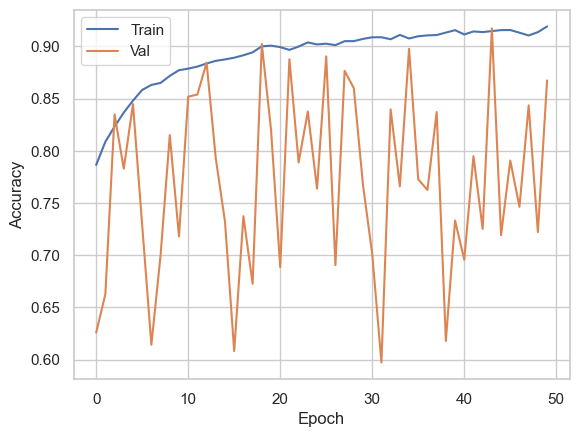

In [73]:
import matplotlib.pyplot as plt

# 1) Accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.xlabel('Epoch'); plt.ylabel('Accuracy')
plt.legend(['Train','Val']); plt.show()


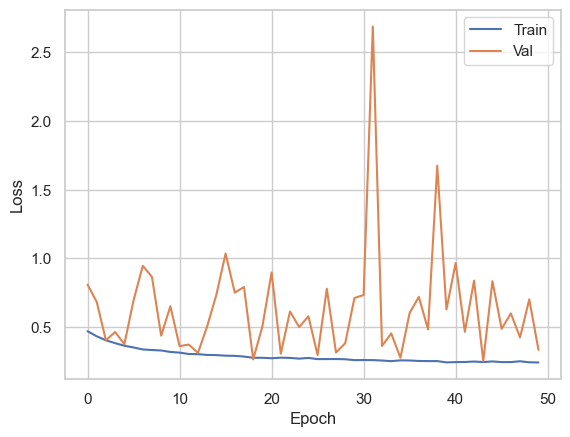

In [74]:
# 2) Loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.legend(['Train','Val']); plt.show()

632/632 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step


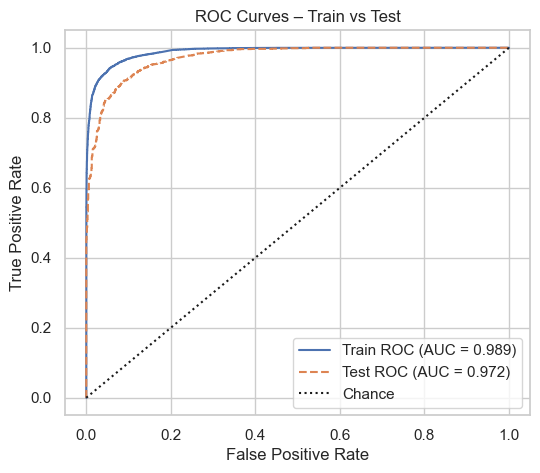

In [75]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# 1. Get probabilities
# If model outputs 2 probs: [p_class0, p_class1]
y_train_prob = model.predict(X_train)[:, 1]   # positive class only
y_test_prob  = model.predict(X_test)[:, 1]


# 2. Compute ROC points and AUC
fpr_tr, tpr_tr, _ = roc_curve(y_train, y_train_prob)
auc_tr = auc(fpr_tr, tpr_tr)

fpr_te, tpr_te, _ = roc_curve(y_test, y_test_prob)
auc_te = auc(fpr_te, tpr_te)

# 3. Plot
plt.figure(figsize=(6,5))
plt.plot(fpr_tr, tpr_tr, label=f'Train ROC (AUC = {auc_tr:.3f})')
plt.plot(fpr_te, tpr_te, label=f'Test ROC (AUC = {auc_te:.3f})', linestyle='--')
plt.plot([0,1], [0,1], 'k:', label='Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves – Train vs Test')
plt.legend()
plt.grid(True)
plt.show()


In [37]:
imgs = np.expand_dims(X_test[2880:2887], axis=0)
prob = model.predict(imgs[0])
prob

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


array([[0.19302814, 0.80697185],
       [0.30623606, 0.693764  ],
       [0.00856398, 0.99143606],
       [0.15166675, 0.8483333 ],
       [0.69929636, 0.3007037 ],
       [0.36882654, 0.63117343],
       [0.3519595 , 0.6480405 ]], dtype=float32)

In [76]:
# predicted class probabilities from softmax
y_prob_all = model.predict(X_test)          # shape (n_samples, 2)

# choose prob for class 1 (seizure)
y_prob = y_prob_all[:, 1]

# class predictions
y_pred = np.argmax(y_prob_all, axis=1)      # 0 or 1


91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step


In [77]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    cohen_kappa_score, confusion_matrix, roc_auc_score
)

acc   = accuracy_score(y_test, y_pred)
prec  = precision_score(y_test, y_pred)
sens  = recall_score(y_test, y_pred)        # sensitivity = recall for positive class
cm    = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
spec  = tn / (tn + fp)                      # specificity
f1    = f1_score(y_test, y_pred)
kappa = cohen_kappa_score(y_test, y_pred)
auc   = roc_auc_score(y_test, y_prob)
err   = 1 - acc

print("Accuracy:", acc)
print("Error:", err)
print("Precision:", prec)
print("Sensitivity (Recall):", sens)
print("Specificity:", spec)
print("F1-score:", f1)
print("Kappa:", kappa)
print("AUC:", auc)
print("Confusion matrix:\n", cm)


Accuracy: 0.8624870107377901
Error: 0.1375129892622099
Precision: 0.806401652039236
Sensitivity (Recall): 0.9861111111111112
Specificity: 0.7122026093630084
F1-score: 0.8872479409258733
Kappa: 0.7155072677092003
AUC: 0.9721456700543424
Confusion matrix:
 [[ 928  375]
 [  22 1562]]


#####   Explainable AI - SHAP ####

In [42]:
import shap
import numpy as np

# 1) background for GradientExplainer (small subset of train)
background = X_train[np.random.choice(len(X_train), 1000, replace=False)]

# 2) build explainer
explainer = shap.GradientExplainer(model, background)

# 3) get SHAP values for some test samples
X_sample = X_test[2810:2811]     # (100, 19, 33, 6, 1)
shap_values = explainer.shap_values(X_sample)  # list; for binary: len=1
sh = shap_values[0]         # (100, 19, 33, 6, 1) [100-epochs, 19-channels, 33-freq bin, 6-time bin, 1-channel of TF img that is power]


f:\Anaconda\envs\new_env\Lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(1, 19, 11, 6, 1))']
  warnings.warn(msg)


In [43]:
print(shap_values[0].shape)
print(sh.shape)
print(shap_values.shape)

(19, 11, 6, 1, 2)
(19, 11, 6, 1, 2)
(1, 19, 11, 6, 1, 2)


In [47]:
shap_class1 = shap_values[:, :, :, :, :, 1]
shap_class0 = shap_values[:, :, :, :, :, 0]

print(shap_class0.shape)

(1, 19, 11, 6, 1)


In [48]:
mean_shap = np.mean(shap_class1, axis=0)   # (19, 5)

mean_shap.shape

(19, 11, 6, 1)

In [49]:
mean_shap_1 = np.mean(mean_shap, axis=3)   # (19, 5)

mean_shap_1.shape

(19, 11, 6)

In [50]:
mean_shap_time = np.mean(mean_shap_1, axis=2)   # (19, 5)

mean_shap_time.shape

(19, 11)

In [51]:
mean_shap_freq = np.mean(mean_shap_1, axis=1)

mean_shap_freq.shape

(19, 6)

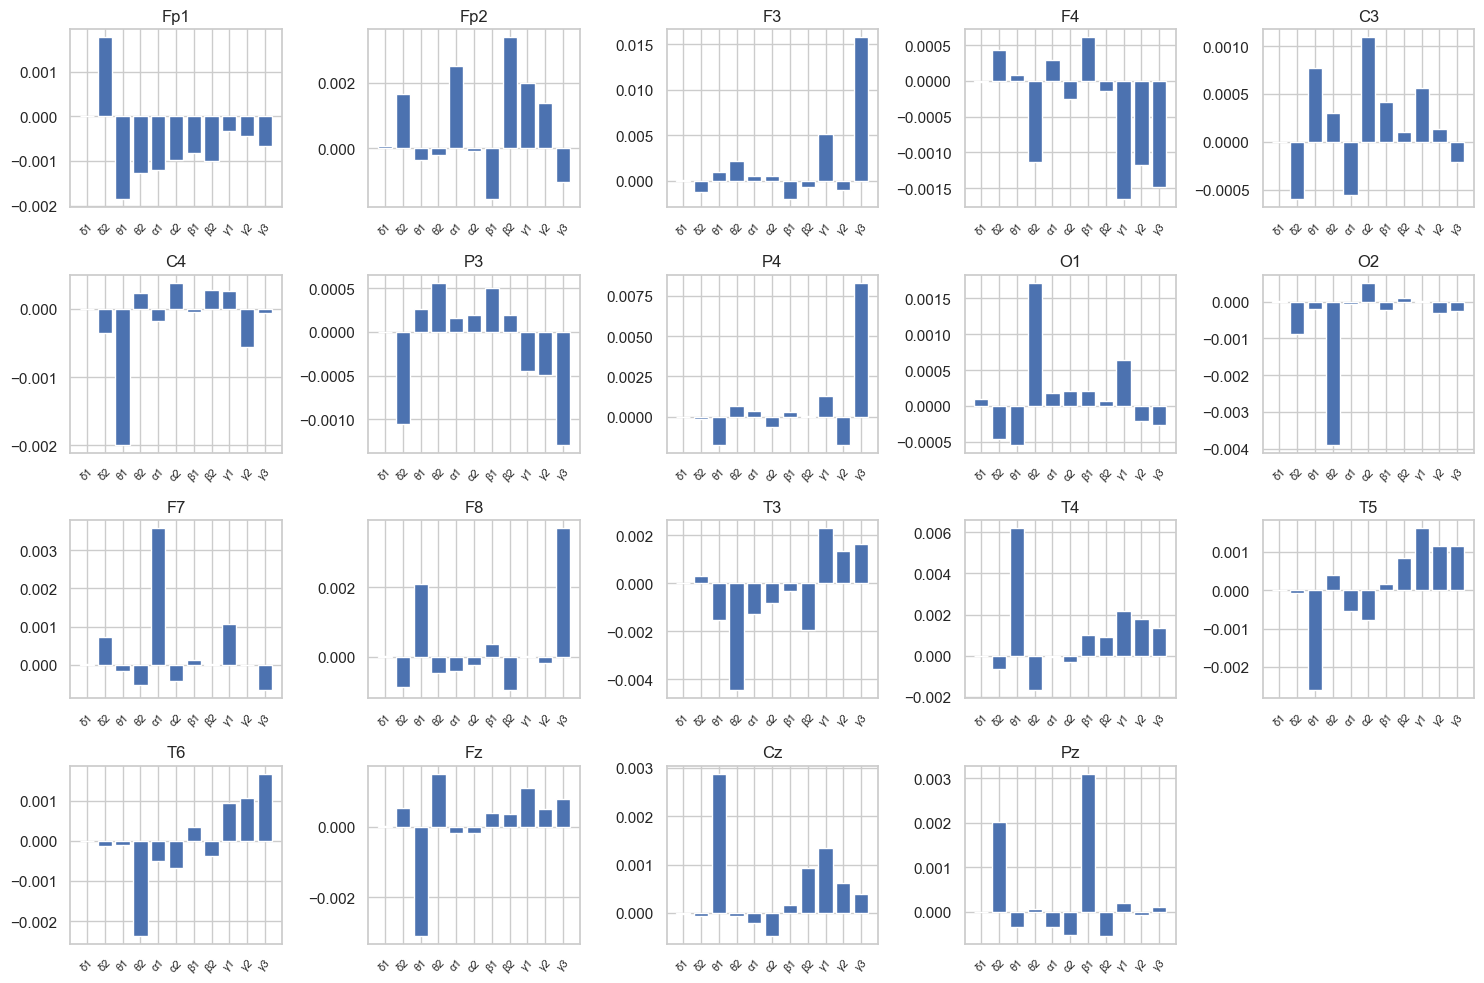

In [52]:
import matplotlib.pyplot as plt
import numpy as np

electrode_names = [
    'Fp1','Fp2','F3','F4','C3','C4','P3','P4',
    'O1','O2','F7','F8','T3','T4','T5','T6',
    'Fz','Cz','Pz'
]

# mean_shap has shape (19, 11)
# mean_shap[e, f] = SHAP value for electrode e, frequency bin f

fig, axes = plt.subplots(4, 5, figsize=(15, 10))
axes = axes.flatten()

freq_labels = ['δ1','δ2','θ1','θ2','α1','α2','β1','β2','γ1','γ2','γ3']  # 11 labels as an example

for i in range(19):
    axes[i].bar(range(11), mean_shap_time[i, :])
    axes[i].set_title(electrode_names[i])
    axes[i].set_xticks(range(11))
    axes[i].set_xticklabels(freq_labels, rotation=45)
    axes[i].tick_params(axis='x', labelsize=8)

axes[19].axis('off')
plt.tight_layout()
plt.show()


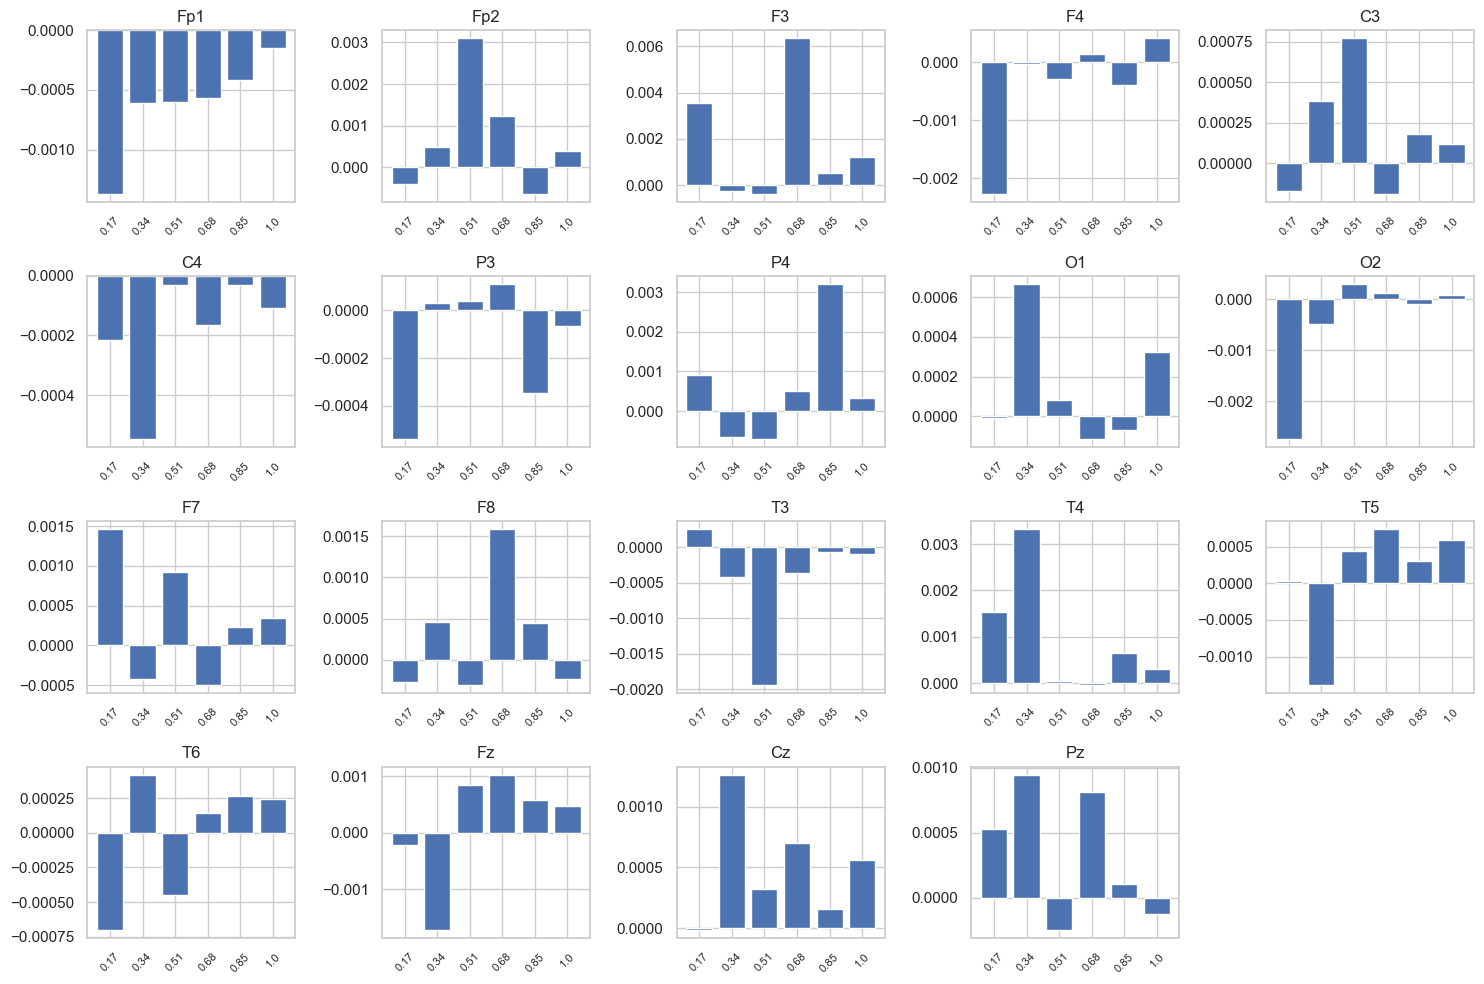

In [53]:
import matplotlib.pyplot as plt
import numpy as np

electrode_names = [
    'Fp1','Fp2','F3','F4','C3','C4','P3','P4',
    'O1','O2','F7','F8','T3','T4','T5','T6',
    'Fz','Cz','Pz'
]

# Assuming mean_shap_freq_time has shape (19, 6) after averaging over frequency
# mean_shap_freq_time[e, t] = SHAP value for electrode e, time bin t

fig, axes = plt.subplots(4, 5, figsize=(15, 10))
axes = axes.flatten()

time_labels = ['0.17','0.34','0.51','0.68','0.85','1.0']  # 6 time bins

for i in range(19):
    axes[i].bar(range(6), mean_shap_freq[i, :])
    axes[i].set_title(electrode_names[i])
    axes[i].set_xticks(range(6))
    axes[i].set_xticklabels(time_labels, rotation=45)
    axes[i].tick_params(axis='x', labelsize=8)

axes[19].axis('off')
plt.tight_layout()
plt.show()


####   SHAP Values for CLass0   ####

In [55]:
mean_shap_0 = np.mean(shap_class0, axis=0)   # (19, 5)

mean_shap_0.shape

(19, 11, 6, 1)

In [56]:
mean_shap_0_1 = np.mean(mean_shap_0, axis=3)
print(mean_shap_0_1.shape)

(19, 11, 6)


In [57]:
mean_shap_0_time = np.mean(mean_shap_0_1, axis=2)

print(mean_shap_0_time.shape)

(19, 11)


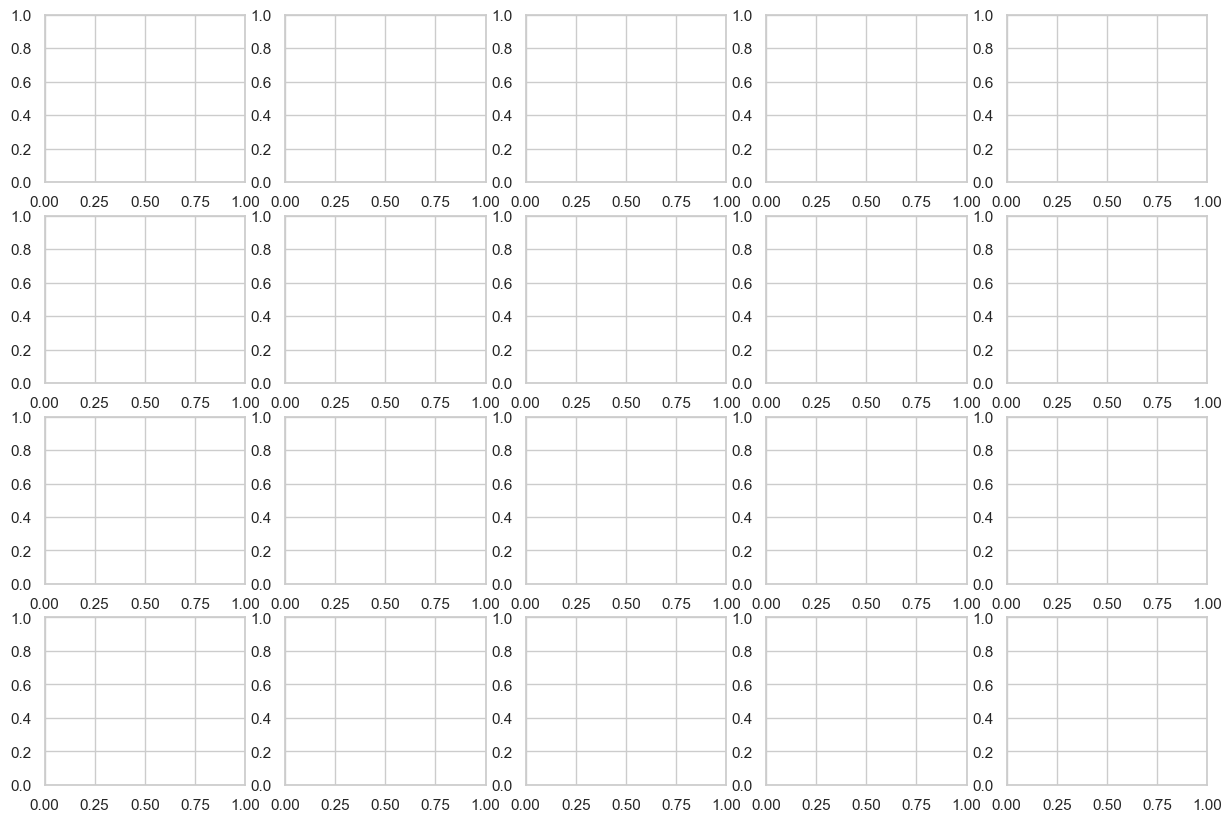

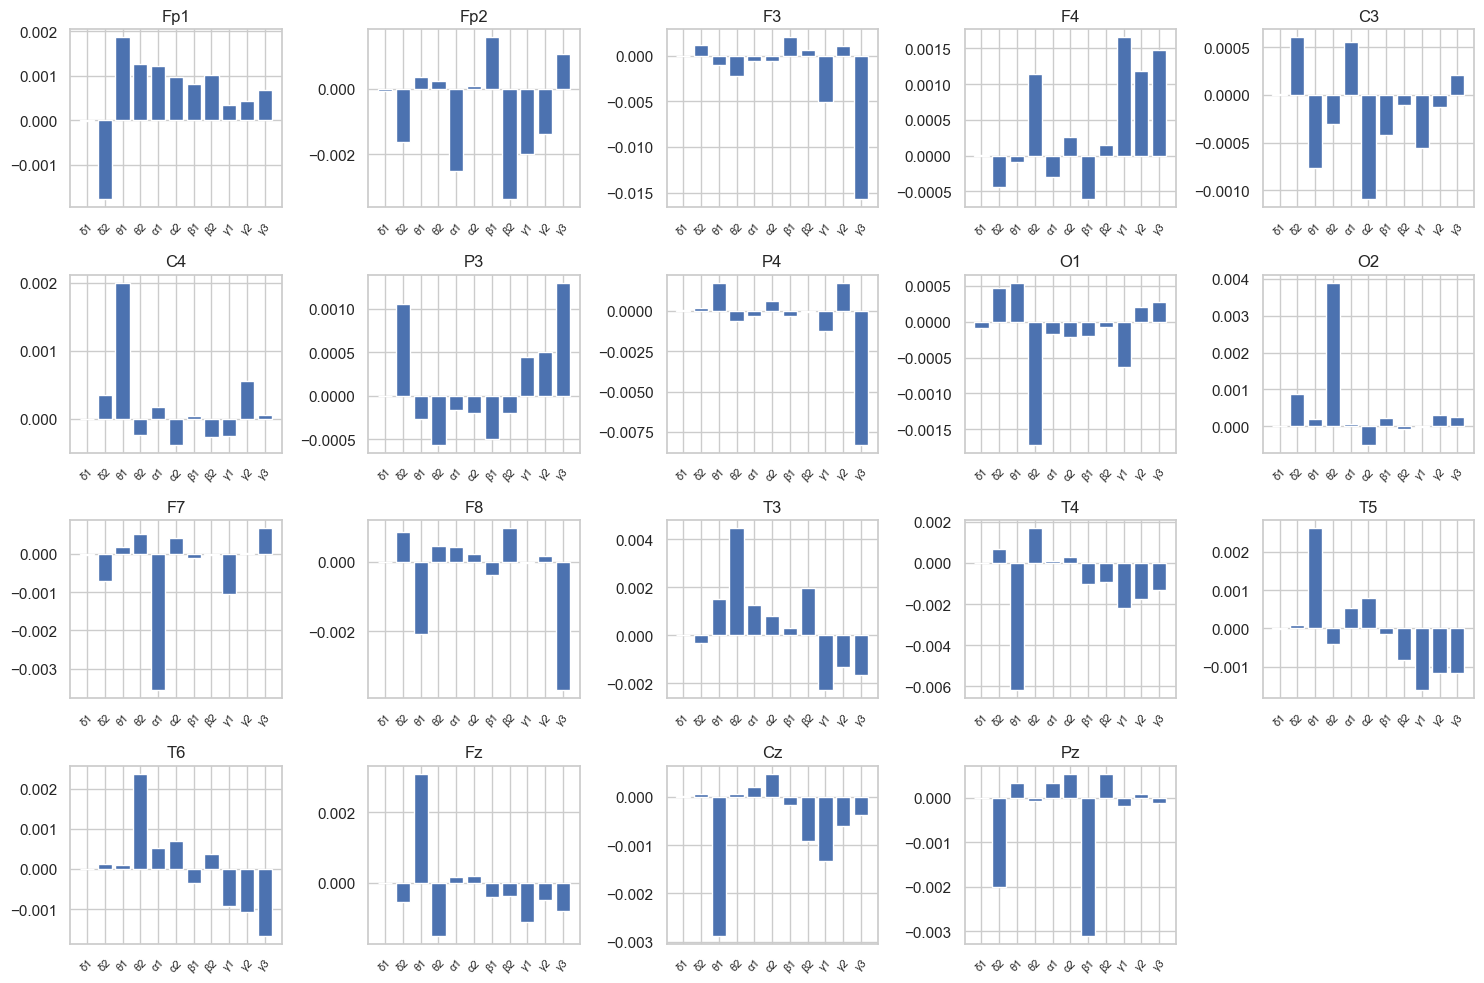

In [58]:
import matplotlib.pyplot as plt
import numpy as np

electrode_names = [
    'Fp1','Fp2','F3','F4','C3','C4','P3','P4',
    'O1','O2','F7','F8','T3','T4','T5','T6',
    'Fz','Cz','Pz'
]

# mean_shap has shape (19, 11)
# mean_shap[e, f] = SHAP value for electrode e, frequency bin f

fig, axes = plt.subplots(4, 5, figsize=(15, 10))
axes = axes.flatten()

freq_labels = ['δ1','δ2','θ1','θ2','α1','α2','β1','β2','γ1','γ2','γ3']  # 11 labels as an example

for i in range(19):
    axes[i].bar(range(11), mean_shap_0_time[i, :])
    axes[i].set_title(electrode_names[i])
    axes[i].set_xticks(range(11))
    axes[i].set_xticklabels(freq_labels, rotation=45)
    axes[i].tick_params(axis='x', labelsize=8)

axes[19].axis('off')
plt.tight_layout()
plt.show()


In [71]:
sh_sample = shap_values[0]             # (19, 11, 6, 1, 2)

# drop the image-channel dim
sh_sample = sh_sample[..., 0, :]       # (19, 11, 6, 2)

# separate classes
sh_class0 = sh_sample[..., 0]          # (19, 11, 6)
sh_class1 = sh_sample[..., 1]          # (19, 11, 6)

# average over channels to get freq×time
sh0_freq_time = sh_class0.mean(axis=0) # (11, 6)
sh1_freq_time = sh_class1.mean(axis=0) # (11, 6)
           # should be (33, 6)



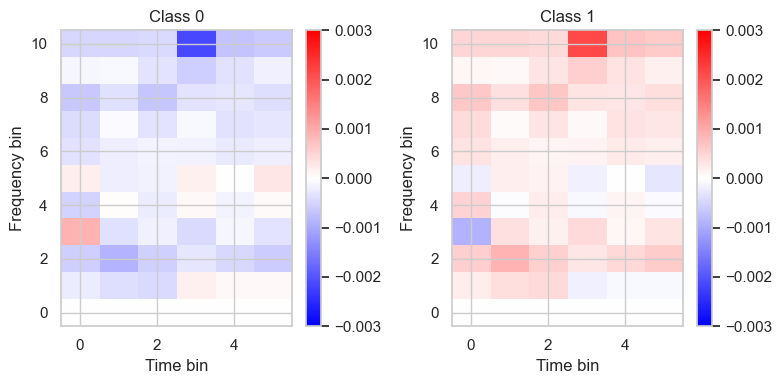

In [72]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

im0 = axes[0].imshow(sh0_freq_time, aspect='auto', origin='lower',
                     cmap='bwr', vmin=-0.003, vmax=0.003)
axes[0].set_title('Class 0')
axes[0].set_ylabel('Frequency bin')
axes[0].set_xlabel('Time bin')
fig.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(sh1_freq_time, aspect='auto', origin='lower',
                     cmap='bwr', vmin=-0.003, vmax=0.003)
axes[1].set_title('Class 1')
axes[1].set_ylabel('Frequency bin')
axes[1].set_xlabel('Time bin')
fig.colorbar(im1, ax=axes[1])

plt.tight_layout()
plt.show()


In [73]:
# full SHAP for this batch
sh_full = shap_values[0]          # (19, 33, 6, 1, 2)

# drop image-channel
sh_full = sh_full[..., 0, :]      # (19, 33, 6, 2)

# separate classes
sh_class0 = sh_full[..., 0]       # (19, 33, 6)
sh_class1 = sh_full[..., 1]       # (19, 33, 6)

# average over time -> (19, 33)
sh0_ch_freq = sh_class0.mean(axis=-1)
sh1_ch_freq = sh_class1.mean(axis=-1)

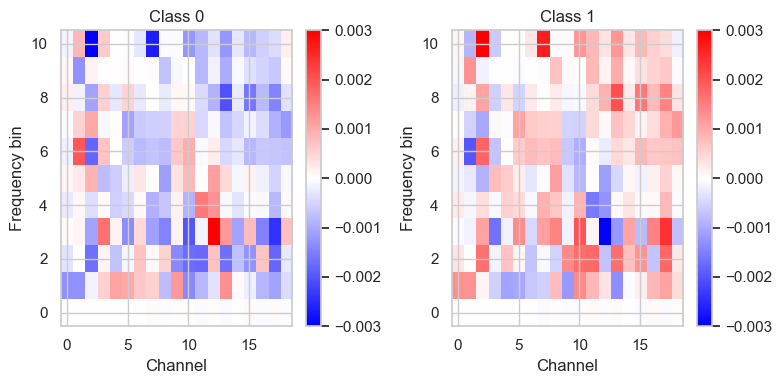

In [74]:
# plot both together
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

im0 = axes[0].imshow(sh0_ch_freq.T, aspect='auto', origin='lower',
                     cmap='bwr', vmin=-0.003, vmax=0.003)
axes[0].set_title('Class 0')
axes[0].set_xlabel('Channel')
axes[0].set_ylabel('Frequency bin')
fig.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(sh1_ch_freq.T, aspect='auto', origin='lower',
                     cmap='bwr', vmin=-0.003, vmax=0.003)
axes[1].set_title('Class 1')
axes[1].set_xlabel('Channel')
axes[1].set_ylabel('Frequency bin')
fig.colorbar(im1, ax=axes[1])

plt.tight_layout()
plt.show()

In [ ]:
i = 2810
X_i = X_test[i:i+1]  # (1, 19, 33, 6, 1)

shap_values = explainer.shap_values(X_i, nsamples=200)  # (1, 19, 33, 6, 1, 2)

# remove batch dim -> (19, 33, 6, 1, 2)
sh_i = shap_values[0]

# drop image-channel dim -> (19, 33, 6, 2)
sh_i = sh_i[..., 0, :]

# split by class
sh_i_class0 = sh_i[..., 0]   # (19, 33, 6) for class 0
sh_i_class1 = sh_i[..., 1]   # (19, 33, 6) for class 1

# background: (B, 19, 33, 6, 1)
probs_bg = model.predict(background, batch_size=32)[:, 1]   # class 1 probs, shape (B,)
phi0 = probs_bg.mean()

# sh_i_class1: SHAP for class 1, shape (19, 33, 6)
phi_sum = sh_i_class1.sum()
approx_prob = phi0 + phi_sum

print("phi0 (mean prob, class 1):", phi0)
print("sum of SHAPs (class 1):", phi_sum)
print("phi0 + sum:", approx_prob)

probs_i = model.predict(X_i)[0]     # shape (2,)
prob_i_class1 = float(probs_i[1])   # class 1
print("model prob for sample i, class 1:", prob_i_class1)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
phi0 (mean prob, class 1): 0.7067471
sum of SHAPs (class 1): 0.31144689226695166
phi0 + sum: 1.0181940069253073
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
model prob for sample i, class 1: 0.9996356964111328


In [43]:
# background: (B, 19, 33, 6, 1)
probs_bg = model.predict(background, batch_size=32)[:, 0]  # class 0 probs
phi0 = probs_bg.mean()                                    # baseline for class 0

# sh_i_class0: SHAP for class 0, shape (19, 33, 6)
phi_sum = sh_i_class0.sum()
approx_prob = phi0 + phi_sum

print("phi0 (mean prob, class 0):", phi0)
print("sum of SHAPs (class 0):", phi_sum)
print("phi0 + sum:", approx_prob)

probs_i = model.predict(X_i)[0]     # shape (2,)
prob_i_class0 = float(probs_i[0])   # class 0 prob
print("model prob for sample i, class 0:", prob_i_class0)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
phi0 (mean prob, class 0): 0.29325274
sum of SHAPs (class 0): -0.3114468928434667
phi0 + sum: -0.018194156513434367
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
model prob for sample i, class 0: 0.00036434325738810003


#### GradCAM Analysis ####

In [59]:
for layer in model.layers:
    print(layer.name, layer.output.shape)


input_layer (None, 19, 11, 6, 1)
conv3d (None, 19, 11, 6, 16)
conv3d_1 (None, 19, 11, 6, 16)
conv3d_2 (None, 19, 11, 6, 16)
concatenate (None, 19, 11, 6, 48)
conv3d_3 (None, 19, 11, 6, 32)
batch_normalization (None, 19, 11, 6, 32)
max_pooling3d (None, 10, 6, 3, 32)
dropout (None, 10, 6, 3, 32)
conv3d_4 (None, 10, 6, 3, 32)
batch_normalization_1 (None, 10, 6, 3, 32)
max_pooling3d_1 (None, 5, 3, 2, 32)
dropout_1 (None, 5, 3, 2, 32)
conv3d_5 (None, 5, 3, 2, 16)
batch_normalization_2 (None, 5, 3, 2, 16)
max_pooling3d_2 (None, 3, 2, 2, 16)
dropout_2 (None, 3, 2, 2, 16)
flatten (None, 192)
dense (None, 8)
dropout_3 (None, 8)
dense_1 (None, 2)


In [60]:
import tensorflow as tf
import numpy as np

last_conv_layer_name = "conv3d_5"  # or whatever name you printed
last_output_layer = "dense_1"

grad_model = tf.keras.models.Model(
    inputs=model.inputs,
    outputs=[model.get_layer(last_conv_layer_name).output,
             model.get_layer(last_output_layer).output]
)

In [61]:
def make_gradcam3_heatmap(input_sample, class_index=None):
    """
    input_sample: single EEG TF volume, shape (19, 11, 6, 1)
    class_index: 0 or 1 (if None, uses model's predicted class)
    returns: Grad-CAM heatmap, shape (11, 6) after channel-averaging
    """
    # add batch dimension
    x = tf.cast(input_sample[None, ...], tf.float32)

    with tf.GradientTape() as tape:
        conv_outputs, preds = grad_model(x)
        if class_index is None:
            class_index = int(class_index)
            class_index = tf.argmax(preds[0])
        class_channel = preds[:, class_index]

    # gradient of score wrt conv feature maps
    grads = tape.gradient(class_channel, conv_outputs)              # (1, D, H, W, C)
    pooled_grads = tf.reduce_mean(grads, axis=(1, 2, 3))            # (1, C)

    # weight the feature maps
    conv_outputs = conv_outputs[0]                                  # (D, H, W, C)
    pooled_grads = pooled_grads[0]

    weighted = conv_outputs * pooled_grads                          # broadcast (D,H,W,C)
    cam_3d = tf.reduce_mean(weighted, axis=-1)                      # (D, H, W)

    # ReLU
    cam_3d = tf.nn.relu(cam_3d)
    return cam_3d

In [62]:
imgs = np.expand_dims(X_test[2810], axis=0)
prob = model.predict(imgs)
prob

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step


array([[0.17322545, 0.82677454]], dtype=float32)

In [63]:
# pick an index of a correctly predicted seizure sample
idx = 2810   # for example
x_seizure = X_test[idx]
y_true    = y_test[idx]

# 1) get Grad-CAM maps for seizure class (1)
cam_3d = make_gradcam3_heatmap(x_seizure, class_index=1)  
# cam_ft: (11, 6)  freq × time
# cam_cf: (19, 11) channel × freq


In [64]:
cam_3d.shape

TensorShape([5, 3, 2])

In [66]:
from scipy.ndimage import zoom

cam_3d_np = cam_3d.numpy()          # (D, H, W)
zoom_factors = (19 / cam_3d_np.shape[0],
                11 / cam_3d_np.shape[1],
                 6 / cam_3d_np.shape[2])

cam_resized_3d = zoom(cam_3d_np, zoom_factors, order=1)   # ≈ (19,11,6)


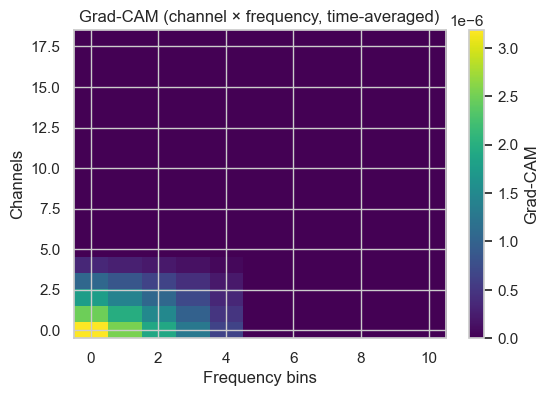

In [67]:
cam_cf = cam_resized_3d.mean(axis=2)   # (19, 11)

plt.figure(figsize=(6,4))
im = plt.imshow(cam_cf, aspect='auto', origin='lower',
                cmap='viridis')
plt.colorbar(im, label='Grad-CAM')
plt.xlabel('Frequency bins')
plt.ylabel('Channels')
plt.title('Grad-CAM (channel × frequency, time-averaged)')
plt.show()


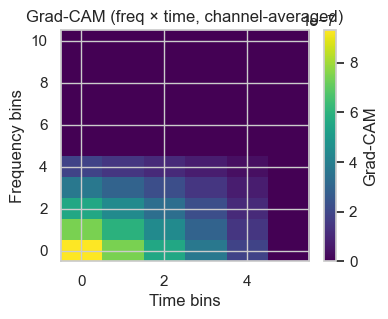

In [68]:
import matplotlib.pyplot as plt
import numpy as np

# Average over channels → (11, 6)
cam_ft = cam_resized_3d.mean(axis=0)

plt.figure(figsize=(4,3))
im = plt.imshow(cam_ft, aspect='auto', origin='lower',
                cmap='viridis')   # or 'hot', 'jet', etc.
plt.colorbar(im, label='Grad-CAM')
plt.xlabel('Time bins')
plt.ylabel('Frequency bins')
plt.title('Grad-CAM (freq × time, channel-averaged)')
plt.show()


C:\Users\Manisha\AppData\Local\Temp\ipykernel_22180\37946962.py:15: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


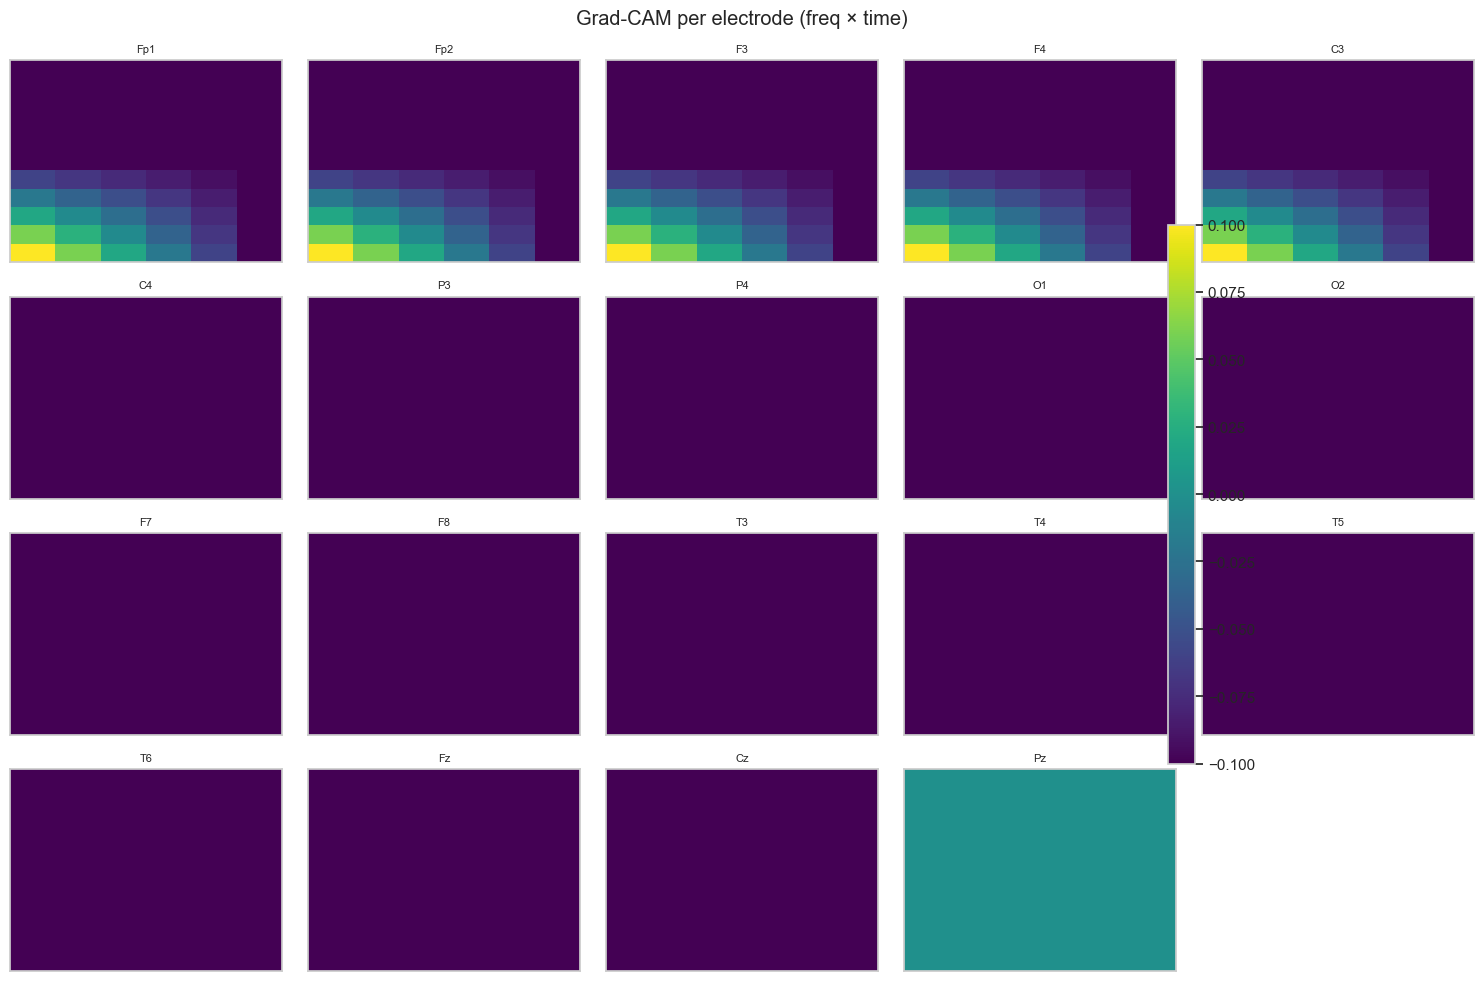

In [69]:
fig, axes = plt.subplots(4, 5, figsize=(15,10))
axes = axes.flatten()

for i in range(19):
    ax = axes[i]
    im = ax.imshow(cam_resized_3d[i], aspect='auto', origin='lower',
                   cmap='viridis')
    ax.set_title(electrode_names[i], fontsize=8)
    ax.set_xticks([])
    ax.set_yticks([])

axes[19].axis('off')
fig.colorbar(im, ax=axes.tolist(), shrink=0.7)
plt.suptitle('Grad-CAM per electrode (freq × time)')
plt.tight_layout()
plt.show()
